# Density-functional theory and Downfolding

In the interest of time, we provide all of the input and output files from a converged DFT and wannierization of the Kohn-Sham bands. However, for completeness and reproducibility, this section outlines the full procedure step by step. These instructions can be used to reproduce our results or adapted to study other correlated materials in the future.

> 🌰 **DFT in a nutshell**: The fundamental variable in DFT is the electron density $\rho(\textbf{r})$. Within the Kohn-Sham formulation of DFT, the interacting many-electron problem is mapped onto a set of non-interacting electrons moving in an effective potential $V_{\text{eff}}[\rho](\textbf{r})$ which is a functional of the electron density. This potential defines an effective single-particle Schrödinger-like equation which can be solved in momentum space as 
$$ H^{\text{DFT}}[\rho](\textbf{k}) |\psi^\sigma_{\nu} (\textbf{k}) \rangle = \epsilon^\sigma_\nu(\textbf{k}) | \psi^\sigma_{\nu}(\textbf{k}) \rangle $$
where $\epsilon^\sigma_\nu(\textbf{k})$ and $|\psi^\sigma_\nu(\textbf{k}) \rangle$ are called the dispersion and wavefunctions, respectively, labeled by crystal momentum $\textbf{k}$, band index $\nu$ and diagonal spin-like index $\sigma$. A new density is given by $\rho(\textbf{k}) = \sum_{\sigma\nu} \langle \psi^\sigma_\nu(\textbf{k}) | \psi^\sigma_\nu(\textbf{k}) \rangle$, and the loop can continue until convergence.
$$
~\\
\begin{array}{ccc}
   \rho(\textbf{r}) & \longrightarrow & V[\rho](\textbf{r}) \\
   \uparrow & & \downarrow \\
   \{ \epsilon^\sigma_\nu(\textbf{k}) \}, \ \{ |\psi^\sigma_\nu(\textbf{k}) \rangle \} & \longleftarrow & H[\rho](\textbf{k})
\end{array}
$$

When performing a DFT calculation, the first step is to obtain a **self-consistently** converged electronic density $\rho$ on a decent yet **coarse** **k**-point grid. Then, from this density, we can easily construct the potential $V[\rho]$ on a **finer grid** and solve only once, that is, **non-self-consistently**.

In this tutorial, we show how to perform DFT calculations using Quantum Espresso and then use Wannier90 to construct a set of localized orbitals. It is organized as follows:
1. We perform a self-consistent calculation on a coarse grid and present the parameters.
2. We perform a non-self-consistent calculation along a high-symmetry path to generate a DFT band structure.
3. We perform a non-self-consistent calculation on a fine grid and use the wavefunction information to construct a set of localized orbitals using Wannier90.
4. We plot, compare, and discuss the results.

## 🧮 1. Density-functional theory with Quantum ESPRESSO

We perform an electronic structure calculation based on Kohn-Sham density-functional theory (DFT), as implemented in the plane-wave pseudopotential code [Quantum ESPRESSO](https://www.quantum-espresso.org). The goal of this step is to obtain the self-consistently converged electronic density on a coarse **k**-grid.

#### 🔧 Quantum ESPRESSO input file

The input file for this calculation can be found here: ``data/scf/lco.scf.in`` and you should take a look while reading this section. Note that for more details about the parameters or Quantum Espresso in general, we refer the reader to [their tutorials](https://www.quantum-espresso.org/tutorials/).

Quantum ESPRESSO input files are organized into several sections:
- ``&control``, ``&system``, and ``&electrons`` define the type of calculation, where important information is read/written, and a few parameters;
- `ATOMIC_SPECIES` contains the different atoms in the unit cell and their respective pseudopotentials.
- `CELL_PARAMETERS` defines the translational lattice vectors.
- `ATOMIC_POSITIONS` are the positions of each atom in the unit cell in units of the translational lattice vectors.
- `K_POINTS` defines the size of the **k**-point grid.

For this calculation, we perform a **self-consistent field (SCF)** run (``calculation = 'scf'``), which means the DFT equations will be solved iteratively until the charge density is converged.

There are many tunable parameters in this DFT calculation. However, three key settings should always be checked for convergence:
- **Plane-wave basis cutoff energy**: ``ecutwfc`` (wavefunctions), ``ecutrho`` (charge density);
- **Brillouin zone sampling**: ``K_POINTS`` grid;
- **Smearing**: `degauss` effective temperature, important for metallic or small-gap systems to ensure smooth convergence.

#### ▶️ Running the SCF calculation

Quantum ESPRESSO provides a suite of executables for performing different types of calculations. To run the SCF calculation, we use the ``pw.x`` executable. From the terminal, use one of the following commands:
```bash
pw.x < lco.scf.in > lco.scf.out  # write output directly to file
```
> 💡 **Tip**: You can monitor convergence in `lco.scf.out` by tracking the total energy. For example, ``grep Energy lco.scf.out``.

## 📈 2. Band structure calculation with Quantum ESPRESSO

With the SCF calculation converged on a coarse grid, we can now compute the Kohn-Sham eigenvalues for a denser set of **k**-points. At this stage, we are particularly interested in the low-energy electronic structure. Therefore, inspecting the **band structure**, the eigenvalues of the Kohn-Sham Hamiltonian along high-symmetry paths in the Brillouin zone is essential. We are also interested in the **orbital character** of these bands.

This part proceeds in three steps:
1. Compute the Kohn-Sham eigenvalues along a high-symmetry path;
2. Extract the band information;
3. Compute the overlap between the resulting wave functions and hydrogen-like orbitals at the atomic positions;

After that, we have all the information needed to plot the band structure with the orbital characters.

### ⚙️ 2.1 High-symmetry path
The band structure is computed by evaluating the Kohn-Sham Hamiltonian along a **user-defined path of k-points** in reciprocal space. Quantum Espresso will use the converged density from the previous step,  and solve the resulting Kohn-Sham Hamiltonian along this path. This is called a **non-self-consistent field (NSCF)** calculation as the charge density remains fixed.

The input file for this calculation can be found here: ``data/bands/lco.bnd.in``. It is similar to the previous input file, but with three important differences:
- `calculation        = 'bands',`: tells Quantum Espresso to perform a NSCF calculation for the bands, starting from a converged density in `outdir             = '../tmp/'`;
- `diago_full_acc     = .true.,`: ensures full diagonalization of the Kohn-Sham Hamiltonian, that is, no iterative or approximate solvers are used. This allows for more accurate computation of the eigenvalues in a single run.
- `K_POINTS crystal_b`: specifies the high-symmetry path. The $k$-points are specified in the reciprocal lattice vectors of the crystal and the last integer of each line is the number of points in the segment.

> 💡**Note**: The Brillouin zone here corresponds to the **body-centered tetragonal** structure of La$_{2}$CuO$_{4}$ (space group I4/mmm). The high-symmetry points are chosen accordingly to reproduce the familiar two-dimensional band structure one would get from a tight-binding model on a square lattice.

#### ▶️ Run the band structure calculation
We run the script with the `pw.x` executable:
```bash
pw.x < lco.bnd.in > lco.bnd.out
```

### ⚙️ 2.2 Extracting the band information
The previous calculation generates data that is not very friendly for plotting. Therefore, Quantum Espresso has an executable to help us, called `bands.x`. The input file for this executable is found here: ``data/bands/lco.bands.in``. It only contains the path to the other needed information, and the file to which it writes the data to be plotted.

#### ▶️ Run the bands post-processing
We run the executable with:
```bash
bands.x < lco.bands.in > lco.bands.out
```
#### 🧠 Output file
The output file of interest can be found here: `data/bands/lco.bands`. Each block of lines corresponds to a single band with index $\nu$, and the different lines each correspond to the information for a **k**-point along the high-symmetry path. The first entry is the $x$-value along the high-symmetry path and the second is the eigenvalue $\epsilon_{\nu}(\textbf{k})$. In the calculation we have performed, only one spin was considered.


### ⚙️ 2.3 Orbital character
The pseudopotentials that define the atoms in `ATOMIC_SPECIES` of the scf file contain information about atomic-like orbitals in the form of hydrogen-like orbitals. Note that these orbitals are expressed as **real spherical harmonics**. Thus, Quantum Espresso can utilize the wave functions that represent the ground state at a given **k**-point and project them onto those atomic orbitals. In other words, given 
1. $|\Psi^\sigma_{\nu} (\textbf{k}) \rangle$ the wave function of a band $\nu$ with spin $\sigma$ at **k** computed in step 2.1 and
2. $| \tilde \chi^{\textbf{R}}_{lm} (\textbf{k}) \rangle$ the Bloch transform of an atomic orbital with quantum number $l$ and $m$ of the atom at the position **R**,
   
the orbital character of the band $\nu$ with spin $\sigma$ at **k** in the $lm$ channel of the atom at **R** is given by
$$ \Big|\langle \Psi^\sigma_\nu (\textbf{k}) | \tilde{\chi}^{\textbf{R}}_{lm} (\textbf{k}) \rangle \Big|^2.$$

The input file for this calculation can be found here: ``data/fatbands/lco.kpdos.in``. The important part is that we are now using the card `&projwfc`, used by the `projwfc.x` executable to compute the projections of the wave functions.

#### ▶️ Run the band structure calculation
We run the script with the `projwfc.x` executable:
```bash
projwfc.x < lco.kpdos.in > lco.kpdos.out
```

#### 🧠 Output file
If you look inside the `fatbands/` directory after a calculation, you will find a file named `lco.proj.dat.projwfc_up` which contains the orbital characters of each band at each **k**-point along the high-symmetry path. The first important line is `1    1 La   5S     1    0    1`, which means it will display the first (1) set of characters of the atom #1 of La type for the 5S orbital characters which is the first (1) shell, with $l=0$ and the first real spherical harmonic $m = 1$. The next 8040 lines are the associated characters for the 201 kpts and 40 bands (201*40=8040) of this calculation.

In our case, we are interested in the Cu-3d characters. The copper atom is #3, so we will extract this information by running the following command:
```bash
grep "3 Cu   3D" -A 8040 lco.proj.dat.projwfc_up | grep -v "Cu" > fatbands.dat
```

We have now stored this data in the `data/fatbands/fatbands.dat` file.

We will plot the results later in the exercises section 4 of this tutorial. However, we show a preview of the figure here, for the orbital character in the Cu-$d_{x^2-y^2}$ channel. You can see that this orbital dominates the single band at the Fermi level. Thus, it serves as a good candidate for a single-band model of La$_2$CuO$_4$, which we will construct in the next section.

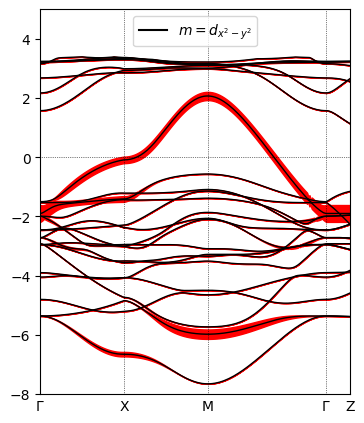

## 🔗 3. Quantum Espresso interfaced with Wannier90

With the information provided by the orbital characters of the bands around the Fermi level, we are now ready to construct the set of local orbitals that will be used for DMFT.

To connect DFT to DMFT, we need to construct a set of localized orbitals. We will now construct a low-energy tight-binding model Hamiltonian by projecting the Kohn-Sham states onto **maximally localized Wannier functions** using Wannier90, which is tightly integrated with Quantum ESPRESSO.

Below we outline the key steps required to perform this Wannierization procedure:

#### 🧩 1: Prepare the input files
After completing a SCF run with Quantum ESPRESSO, we need to run a NSCF run on a dense **k**-mesh in the full Brillouin zone. This is what Wannier90 will use to constrain the Wannier functions. This is provided in ``data/mlwf/lco.nscf.in``, which essentially tells Quantum Espresso to run a single iteration on a fine **k**-grid.

#### 📝 2: Create the Wannier90 input file
We are now ready to define the localized orbitals that Wannier90 will construct. To do so, it needs information to read the Quantum Espresso files generated from the NSCF calculation, along with instructions about which orbitals to construct and how. For this specific tutorial, please see ``data/mlwf/lco.win``.

Among the information needed, it requires basic information such as the unit cell vectors and atomic coordinates, respectively provided in the `unit_cell_cart` and the `atoms_cart` structures. ``mp_grid`` and ``kpoints`` specify the **k**-grid.

The choice of localized orbitals is given by
```bash
num_wann = 1
begin projections
Cu:dx2-y2:x=1,0,0
end projections
```
which indicates it will construct a single Wannier orbital, centered at the Cu atom, with the $d_{x^2-y^2}$ character where $x$ is defined along the $(1, 0, 0)$ direction. `num_bands = 5` specifies only five Kohn-Sham bands should be used and `exclude_bands : 1-28,34-40` means it will use the band numbers 29 to 33.

The file also contains data about things to plot for postprocessing purposes. In particular, we are interested in plotting the resulting band structure in the orbital basis.

Finally, `write_hr = true` and `write_tb = true` are required to plot the Hamiltonian $H(\textbf{r})$ and in tight-binding form. Those files are essential for later purposes when we will perform DMFT.

For more information about Wannierization, please refer to the Wannier90 documentation, or see a tutorial such as [this one](https://docs.epw-code.org/_downloads/f2f39ac545ca12dc2838f7359b3633a9/Mon.4.Pizzi.pdf).

#### ▶️ 3: Running the NSCF calculation
<span style="color:red;">[OG: This should be step 2, no?]</span>
```bash
pw.x < lco.nscf.in > lco.nscf.out
```

#### 🧮 4: Run wannier90.x -pp
<span style="color:red;">[OG: Preprocessing step which produces a ex1.wout file and ex1.nnkp file, that contain the relevant information from the Wannier90 input file in a format to be used in the next step.]</span>
```bash
wannier90.x -pp lco
```

#### ⚙️ 5: Run pw2wannier90.x
<span style="color:red;">[OG: Generates the overlap matrices.]</span>
```bash
pw2wannier90.x < lco.pw2wan.in > lco.pw2wan.out
```

#### 🚀 6: Run wannier90.x
<span style="color:red;">[OG: Actual Wannier90 calculations, maximally localizing the orbitals.]</span>
```bash
wannier90.x lco
```

## 🧩 4. Exercises

Now that we have run both the **DFT** and **Wannier90 interpolation**, we are ready to compare them and build our low-energy tight-binding model. This will validate how well the low-energy tight-binding model reproduces the _ab-initio_ Kohn-Sham bands -- a key sanity check before beginning the DMFT calculation.

We'll write a Python code step-by-step to: 
1. Load and reshape the band structure data
2. Plot the band structure data
3. Load the Wannier90 data and overlay the Wannier model on the DFT bands.

Let's build the plot one step at a time:

### 🧪 Exercise 1: Load and reshape the DFT band structure data
The file ``data/bands/lco_bands.data.gnu`` contains a column of $(k, E)$ pairs. Start by loading the data and reshaping it into a 2D array of shape ``(n_bands, n_kpts)``.
> 💡 **Tips**
> - The numpy library has a utility function ``numpy.loadtxt`` for reading text files.
> - The $k$-points are repeated for each band, so you can get the unique k-points by calling ``numpy.unique``.
> - It is often helpful to ``reshape`` the eigenvalues into an array with shape (n_bands, n_kpts).

In [1]:
import numpy as np 

filename1 = '../data/bands/lco_bands.dat.gnu'
filename2 = '../data/fatbands/fatbands.dat'

# Step 1: load the DFT data
data1 = np.loadtxt(filename1)
data2 = np.loadtxt(filename2)

# Step 2: separate the k-points and eigenvalues
kpts = np.unique(data1[:,0])
bands = data1[:,1].reshape(-1, len(kpts))

# load the orbital character from the second file and swap the axes
orbital_char = 0.3*data2[:, 2].reshape(5, len(kpts), len(bands)).swapaxes(1,2)

### 🧪 Exercise 2: Plot the DFT band structure
Use ``matplotlib`` and our plotting function (``plot_band_structure``) to visualize the DFT band structure. The band structure is defined with respect to the Fermi level, which can be obtained from ``data/scf/lco.scf.out``.

> 💡 **Tip**: Most DFT codes write lots of information to their output files; thus, the Unix program ``grep`` is an extremely useful tool to grab quick information. For the Fermi level, you can run ``grep Fermi data/scf/lco.scf.out``

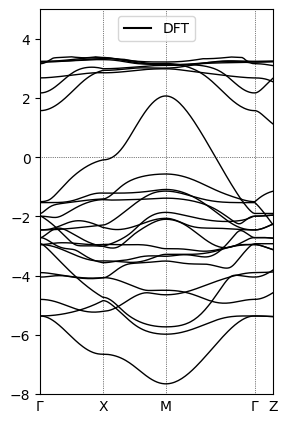

In [2]:
import matplotlib.pyplot as plt
from triqs_tutorials_utils.mpl_interface import plot_band_structure

# Fermi level (grep Fermi data/scf/lco.scf.out)
eF =  12.7367

plt.figure(figsize=(3,5))

# high-symmetry points and labels (from data/bands/lco.bands.out)
high_symm_points = [0.0000, 0.9342, 1.8683, 3.1894, 3.4595] 
high_symm_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z']


# use kpts and bands from Exercise 1
plot_band_structure(kpts, bands, fermi_level=eF, high_symm_points=high_symm_points, high_symm_labels=high_symm_labels)

plt.plot([], [], color='k', label='DFT')
plt.legend(loc='upper center', ncols=2, fontsize=10)
plt.ylim(-8, 5)

plt.show()

### 🧪 Exercise 3: Plot "Fat Bands"
Now that you've successfully plotted the DFT band structure, we will plot the band structure with the orbital content overlaid, often called "fatbands". This is a typical practice to identify the dominant orbital content of a Kohn-Sham state at a specific energy and $k$-point. In this exercise, you will loop over the orbital characters (``orbital_char`` loaded in Exercise 1) and pass the band structure data along with the orbital character data to plot the fat bands. The orbitals are ordered as: $d_{z^{2}}$, $d_{xz}$, $d_{yz}$, $d_{x^{2}-y^{2}}$, and $d_{xy}$.

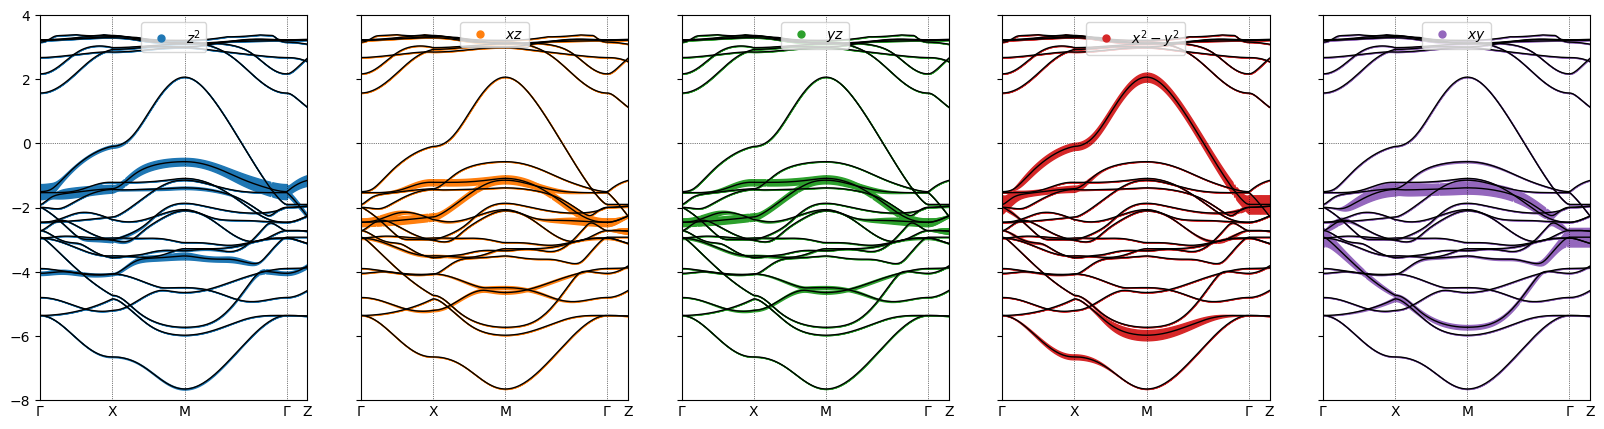

In [3]:
fig, ax = plt.subplots(1, 5, figsize=(20,5),sharey=True)

# high-symmetry points and labels (from data/bands/lco.bands.out)
high_symm_points = [0.0000, 0.9342, 1.8683, 3.1894, 3.4595] 
high_symm_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z']

orbital_labels = ['z^{2}', 'xz', 'yz', 'x^{2}-y^{2}', 'xy']

for (i, orb) in enumerate(orbital_labels):
    # use kpts and bands from Exercise 1
    plot_band_structure(kpts, bands, 
                        orb_char=orbital_char[i], 
                        axes=ax[i], 
                        orb_char_color=f"C{i}",
                        fermi_level=eF, 
                        high_symm_points=high_symm_points, 
                        high_symm_labels=high_symm_labels)
    
    ax[i].plot([], [], 'o', ms=5, color=f"C{i}", label=r'$%s$' %orb)
    ax[i].legend(loc='upper center', ncols=2, fontsize=10)
    ax[i].set_ylim(-8, 4)
plt.show()

### 🧪 Exercise 5: Tight-binding from Wannier90 using TRIQS
Now that we have familiarized ourselves with the DFT data by plotting the band structure and analyzing the orbital content of the bands, we can construct our local orbitals. We choose to use maximally-localized Wannier functions to create a local orbital for the Cu-$d_{x^{2}-y^{2}}$ orbital. As outlined above, this procedure gives a real-space Hamiltonian, $H(R)$. We will use this Hamiltonian as our non-interacting tight-binding model to which we will then add local interactions.

**We are now at the interface between DFT and TRIQS.** Let's load our DFT data, or more generally our one-body physics data, into a TRIQS object called ``one_body_elements``. One-body elements abstracts away the one-body physics into a single object that can be used when writing DMFT loops. For this case, the one-body physics consists of the dispersion (in the form of a tight-binding Hamiltonian) and a local space. The local space corresponds to a definition of local (atomic-like) orbitals.

Run the cell below to produce the band structure for our tight-binding model. Don't worry, we will explain all of the pieces in much more detail in the next tutorial.

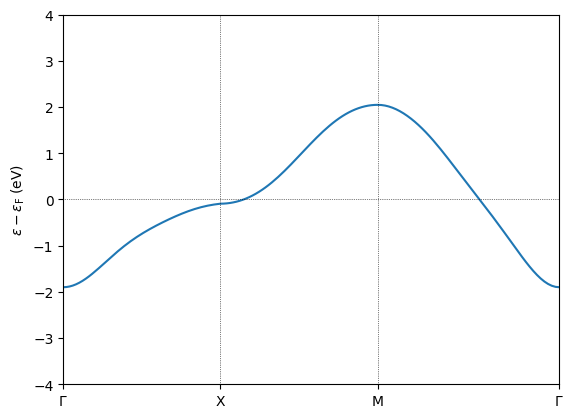

In [4]:
import triqs_modest as modest
from triqs.lattice.utils import k_space_path

# high-symmetry points in bct zone
G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]

# create high-symmetry path
segments = [(G,X), (X,M), (M, G)]
k_points, k_lin, k_ticks = k_space_path(segments, num=50)

# load in obe or the TB hamiltonian
obe  = modest.one_body_elements_from_wannier90("../data/mlwf/lco",  "NonPolarized", [modest.AtomicOrbs(l=2,dim=1,dft_idx=0,cls_idx=0)])

# compute the dispersion along the high-symmetry directions
e_k = obe.H[0](k_points).real.reshape(1,-1)

# plot the dispersion and decorate
plt.plot(k_lin, e_k[0,:] - eF)
for k in k_ticks: plt.axvline(k, color='k', lw=0.5, ls='dotted')
plt.axhline(0, color='k', lw=0.5, ls='dotted')
plt.xticks(k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$'])
plt.ylim(-4,4); plt.xlim(min(k_lin), max(k_lin))
plt.ylabel(r'$\varepsilon-\varepsilon_{\mathrm{F}}$ (eV)')
plt.show()

### 🧪 Exercise 6: Summarize

Let's take a moment to describe our results in a bit more detail. In a few sentences, can you describe the most salient features of the band structure of La$_{2}$CuO$_{4}$, as well as the features of our low-energy model?

The band structure of La$_{2}$CuO$_{4}$ shows a dispersive two-dimensional band derived from the Cu-$d_{x^{2}-y^{2}}$ orbital at low-energy. The overall bandwidth $W$ spans around $\sim 4$ eV. The remaining complex bands are formed from the hybridized O($2p)$ and Cu($3d$) orbitals. There are a total of 17 bands (5 Cu and 12 O).

# 🎉 Nice!
You've finished the exercises for this tutorial! Now you are ready to start building your DMFT calculation.